In [35]:
import tarfile
import os
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torchvision.utils as vutils

# Extracting the uploaded file
with tarfile.open('/content/drive/MyDrive/Colab Notebooks/flower_photos.tgz', 'r:gz') as tar:
    tar.extractall(path='./data')

# Transformations: Resize to 64x64 and Normalize to [-1, 1] for GANs
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = datasets.ImageFolder(root='./data/flower_photos', transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2)

print(f"Total images: {len(dataset)} | Classes: {dataset.classes}")

/tmp/ipykernel_8428/3272511569.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='./data')


Total images: 3670 | Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


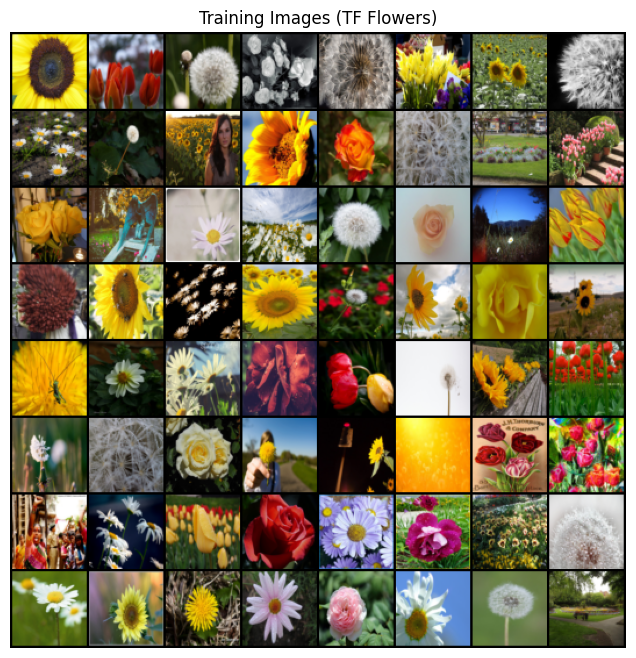

In [36]:
# Get a batch of training images
dataiter = iter(dataloader)
images, labels = next(dataiter)

# Plot the images
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Training Images (TF Flowers)")

grid = vutils.make_grid(images[:64], padding=2, normalize=True)

plt.imshow(np.transpose(grid.cpu(), (1,2,0)))
plt.show()

In [37]:
import torch
import torch.nn as nn

# Configuration
nz = 100        # Size of latent vector (noise)
nc = 3          # Number of channels (RGB)
n_classes = 5   # Daisy, Dandelion, Roses, Sunflowers, Tulips
ngf, ndf = 64, 64

class ConditionalGenerator(nn.Module):
    def __init__(self):
        super(ConditionalGenerator, self).__init__()
        # Embedding for the labels
        self.label_emb = nn.Embedding(n_classes, n_classes)

        self.main = nn.Sequential(
            # Input: noise + label embedding
            nn.ConvTranspose2d(nz + n_classes, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.GELU(),
            # Upsampling layers...
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.GELU(),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.GELU(),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.GELU(),
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        # Concatenate noise and label
        label_output = self.label_emb(labels).unsqueeze(2).unsqueeze(3)
        x = torch.cat([noise, label_output], 1)
        return self.main(x)

In [38]:
import torch
import torchvision.utils as vutils

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Now your setup code will work
nz = 100
fixed_noise = torch.randn(50, nz, 1, 1, device=device)
fixed_labels = torch.tensor([i for i in range(5) for _ in range(10)], device=device)
evolution_snapshots = []

Using device: cuda


In [39]:
class ConditionalDiscriminator(nn.Module):
    def __init__(self):
        super(ConditionalDiscriminator, self).__init__()
        # 5 labels, embedded into a 5-dimensional vector
        self.label_emb = nn.Embedding(n_classes, n_classes)

        self.main = nn.Sequential(
            # Input is (nc + n_classes) x 64 x 64 -> 8 x 64 x 64
            nn.Conv2d(nc + n_classes, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # State: (ndf) x 32 x 32
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # State: (ndf*2) x 16 x 16
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            # State: (ndf*4) x 8 x 8
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),

            # State: (ndf*8) x 4 x 4
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        # 1. Get embedding: shape [batch, 5]
        le = self.label_emb(labels)
        # 2. Reshape: shape [batch, 5, 1, 1]
        le = le.view(labels.size(0), n_classes, 1, 1)
        # 3. Expand: shape [batch, 5, 64, 64] to match image height/width
        le = le.expand(labels.size(0), n_classes, img.size(2), img.size(3))
        # 4. Concatenate: [batch, 3 + 5, 64, 64] -> [batch, 8, 64, 64]
        x = torch.cat([img, le], 1)
        return self.main(x).view(-1)

In [40]:
# Create the models
netG = ConditionalGenerator().to(device)
netD = ConditionalDiscriminator().to(device)

# Initializing weights (Expert Tip: GANs perform better with custom weight init)
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

netG.apply(weights_init)
netD.apply(weights_init)

print("Models initialized and moved to device!")

Models initialized and moved to device!


In [41]:
import torch.optim as optim

# 1. Setup Optimizers
optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion = nn.BCELoss()

num_epochs = 200  # Extended to 200 epochs
evolution_snapshots = []

print("Starting Training Loop...")

for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(dataloader):
        batch_size = images.size(0)
        real_images = images.to(device)
        labels = labels.to(device)

        # --- Update Discriminator ---
        netD.zero_grad()
        # Real images pass with label smoothing
        output = netD(real_images, labels)
        label_real = torch.full((batch_size,), 0.9, device=device) # Label smoothing: 0.9 for real
        lossD_real = criterion(output, label_real)

        # Fake images pass with label smoothing
        noise = torch.randn(batch_size, nz, 1, 1, device=device)
        fake_images = netG(noise, labels)
        label_fake = torch.full((batch_size,), 0.1, device=device) # Label smoothing: 0.1 for fake
        output = netD(fake_images.detach(), labels)
        lossD_fake = criterion(output, label_fake)

        lossD = lossD_real + lossD_fake
        lossD.backward()
        optimizerD.step()

        # --- Update Generator ---
        netG.zero_grad()
        output = netD(fake_images, labels)
        lossG = criterion(output, torch.full((batch_size,), 0.9, device=device)) # Generator wants D to think it's real (0.9)
        lossG.backward()
        optimizerG.step()

    # Capture the "Birth" of your art at the end of every epoch
    with torch.no_grad():
        fake_display = netG(fixed_noise, fixed_labels).detach().cpu()
        grid = vutils.make_grid(fake_display, nrow=10, normalize=True)
        evolution_snapshots.append(grid)

    # Save to Drive
    torch.save(netG.state_dict(), f'flower_gan_epoch_{epoch}.pth')
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss D: {lossD.item():.4f}, Loss G: {lossG.item():.4f}")

Starting Training Loop...
Epoch [1/200] Loss D: 0.7705, Loss G: 4.0032
Epoch [2/200] Loss D: 1.3169, Loss G: 1.6138
Epoch [3/200] Loss D: 0.8425, Loss G: 2.1353
Epoch [4/200] Loss D: 1.8079, Loss G: 1.1265
Epoch [5/200] Loss D: 1.2058, Loss G: 1.7516
Epoch [6/200] Loss D: 1.0969, Loss G: 1.6715
Epoch [7/200] Loss D: 1.3205, Loss G: 1.2089
Epoch [8/200] Loss D: 1.0746, Loss G: 1.4173
Epoch [9/200] Loss D: 1.1776, Loss G: 2.0813
Epoch [10/200] Loss D: 1.5001, Loss G: 1.6963
Epoch [11/200] Loss D: 1.4301, Loss G: 2.8012
Epoch [12/200] Loss D: 1.5527, Loss G: 1.4392
Epoch [13/200] Loss D: 1.5285, Loss G: 0.8014
Epoch [14/200] Loss D: 1.3930, Loss G: 0.8193
Epoch [15/200] Loss D: 1.2910, Loss G: 1.8058
Epoch [16/200] Loss D: 1.2217, Loss G: 1.6865
Epoch [17/200] Loss D: 1.0402, Loss G: 1.3410
Epoch [18/200] Loss D: 1.2835, Loss G: 1.7576
Epoch [19/200] Loss D: 1.1123, Loss G: 1.8076
Epoch [20/200] Loss D: 1.1975, Loss G: 2.3206
Epoch [21/200] Loss D: 1.3080, Loss G: 1.4773
Epoch [22/200] Lo

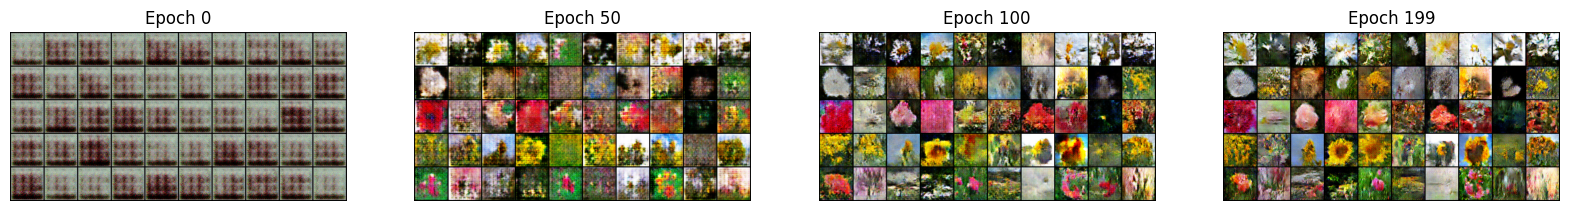

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Select a few key moments (e.g., first, middle, and last epoch)
indices = [0, len(evolution_snapshots)//4, len(evolution_snapshots)//2, len(evolution_snapshots)-1]
fig, axs = plt.subplots(1, len(indices), figsize=(20, 5))

for i, idx in enumerate(indices):
    img = evolution_snapshots[idx]
    axs[i].imshow(np.transpose(img, (1, 2, 0)))
    axs[i].set_title(f"Epoch {idx}")
    axs[i].axis("off")

plt.show()

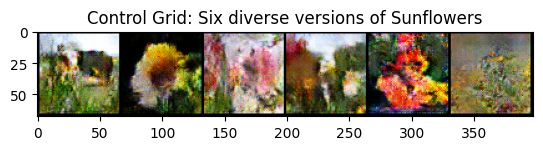

In [43]:
# Select 6 instances of class 3 (Sunflowers)
sunflower_label = torch.full((6,), 3, dtype=torch.long, device=device)
z = torch.randn(6, nz, 1, 1, device=device)

with torch.no_grad():
    samples = netG(z, sunflower_label).cpu()

grid = vutils.make_grid(samples, nrow=6, normalize=True)
plt.imshow(np.transpose(grid, (1, 2, 0)))
plt.title("Control Grid: Six diverse versions of Sunflowers")
plt.show()

### Observation on Generated Images

When attempting to generate 6 diverse versions of sunflowers (class 3) using the trained Conditional GAN, it was observed that the model struggles to produce distinct and accurate images. Instead of diverse sunflower pictures, the generated output often contains merged images and includes colors (e.g., pink) that are not characteristic of sunflowers. This indicates a limitation in the model's ability to consistently generate high-quality, class-specific, and diverse images, suggesting further room for improvement in training stability and image fidelity.

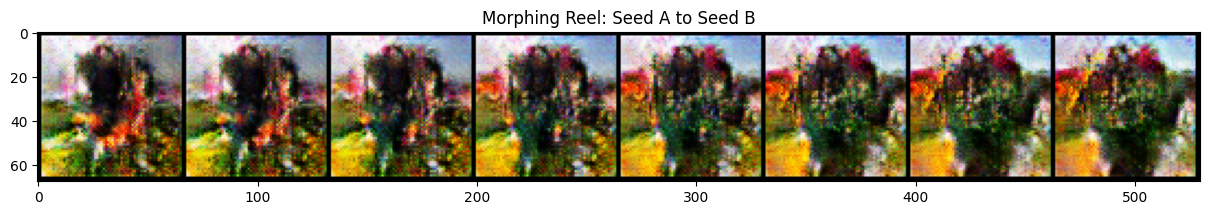

In [44]:
# Pick two seeds
zA = torch.randn(1, nz, 1, 1, device=device)
zB = torch.randn(1, nz, 1, 1, device=device)
target_class = torch.tensor([3], device=device)
# Create 8 steps between them
steps = 8
alpha_values = np.linspace(0, 1, steps)
morphing_images = []

for alpha in alpha_values:
    z_interp = zA * (1 - alpha) + zB * alpha
    with torch.no_grad():
        morphing_images.append(netG(z_interp, target_class).cpu())

# Display the reel
reel = vutils.make_grid(torch.cat(morphing_images), nrow=steps, normalize=True)
plt.figure(figsize=(15,5))
plt.imshow(np.transpose(reel, (1, 2, 0)))
plt.title("Morphing Reel: Seed A to Seed B")
plt.show()

In [45]:
# Check current peak memory usage
peak_memory = torch.cuda.max_memory_allocated(device=device) / 1024**2 # Convert to MB
print(f"Current Convolutional GAN Peak Memory: {peak_memory:.2f} MB")

Current Convolutional GAN Peak Memory: 414.48 MB
